# 의료비 예측 MLP 회귀 모델

### 실습순서
- kaggle에서 데이터(csv) 다운로드
    -https://www.kaggle.com/datasets/mirichoi0218/insurance
- 수치형 / 범주형 데이터 확인
- train/ valid / test 데이터 분리
- 수치형 정규화 / 범주형 One-Hot Encoding
- target 값 로그 변환 및 표준화
- Pytorch Tensor 형태로 데이터 변환
- Dataset / Loader로 미니배치 학습 준비
- 다층 퍼셉트론(MLP) 회귀 모델 설계
- BatchNorm, Dropout, Silu 활성화 함수 사용
- HuberLoss 손실함수, AdamW 최적화 함수, Scheduler, Gradient Clipping, EarlyStopping
- 지표 확인 / 시각화
- 임의의 데이터로 테스트

1. 라이브러리 import

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm
import kagglehub

c:\Users\SJ\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 시드값 고정, CPU/GPU 사용 장치 설정
SEED = 42

random.seed(SEED)                # python random
np.random.seed(SEED)             # numpy random
torch.manual_seed(SEED)          # Pytorch CPU
torch.cuda.manual_seed_all(SEED) # Pytorch GPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용장치 :", device)

사용장치 : cpu


2. 데이터 다운로드

In [3]:
# kaggle에서 데이터셋 다운로드
data_path = kagglehub.dataset_download("mirichoi0218/insurance", path = 'insurance.csv')

df = pd.read_csv(data_path)

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

컬럼 설명
- age : 나이
- sex : 성별
- bmi : 체질량지수
- children : 부양 자녀 수
- smoker : 흡연 여부
- region : 거주 지역
- charges : 의료비 청구 금액(target)

In [5]:
print(df.shape)

df.info()

(1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [8]:
categorical_cols = ['sex','smoker','region']

for col in categorical_cols:
    print(df[col].value_counts()) # 범주형 값 개수

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [9]:
#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

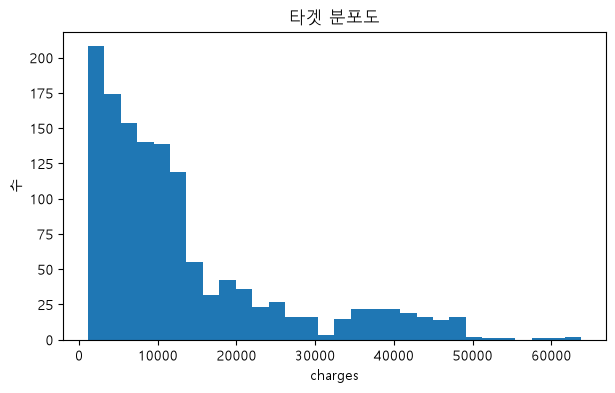

In [10]:
# target 컬럼 분포도
plt.figure(figsize = (7,4))
plt.hist(df['charges'], bins= 30)
plt.title("타겟 분포도")
plt.xlabel("charges")
plt.ylabel("수")
plt.show()


타겟 데이터는 적은 치료비가 많은 상태

<Figure size 700x400 with 0 Axes>

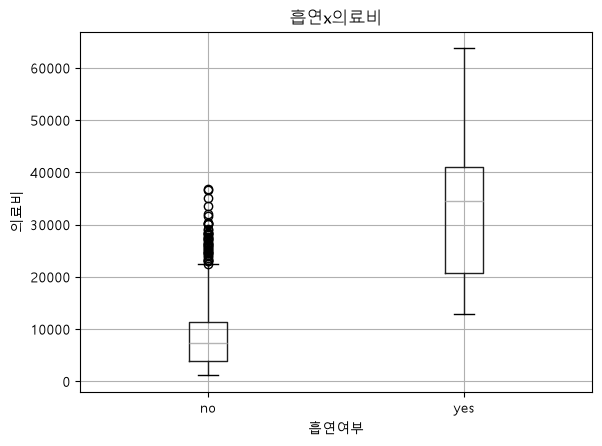

In [11]:
# 흡연 여부에 따른 의료비 차이
plt.figure(figsize = (7,4))
df.boxplot(column = 'charges', by ='smoker') # 흡연여부별 
plt.title("흡연x의료비")
plt.suptitle("")
plt.xlabel("흡연여부")
plt.ylabel("의료비")
plt.show()

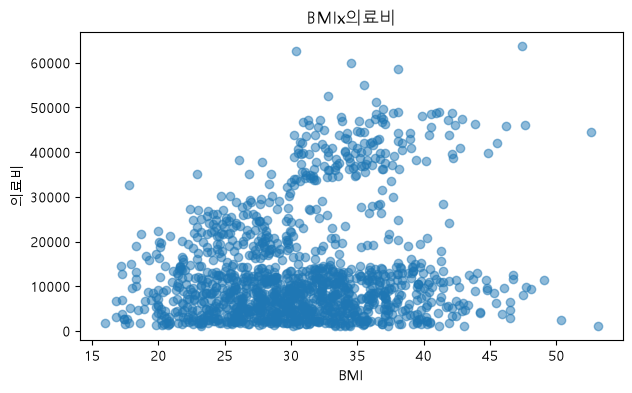

In [12]:
plt.figure(figsize = (7,4))
plt.scatter(df['bmi'], df['charges'], alpha = 0.5)
plt.title("BMIx의료비") # BMI와 의료비 관계 산점도

plt.xlabel("BMI")
plt.ylabel("의료비")
plt.show()

3. 입력 데이터와 정답 데이터 분리

In [13]:
X = df.drop(columns = 'charges')
y = df['charges']

print(X.shape, y.shape)

(1338, 6) (1338,)


In [14]:
# target 컬럼이 왼쪽으로 치우친 형태이므로 로그 변환 적용
y_log = np.log1p(y)



log변환 적용해주니 정규분포와 가까워진 형태로 변환됨

4. train / valid / test 데이터 분리

In [15]:
# test데이터를 8:2 비율로 나눈다
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y_log, 
    test_size = 0.2, 
    random_state = SEED)

# 남은 80% 중 8:2 비율로 train / valid 데이터를 나눈다. (전역 시드값 설정, y_train_valid 비율 유지)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size = 0.2,
    random_state = SEED,
)

print(f"X_train : {X_train.shape}, X_valid : {X_valid.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_valid : {y_valid.shape}, y_test : {y_test.shape}")

X_train : (856, 6), X_valid : (214, 6), X_test : (268, 6)
y_train : (856,), y_valid : (214,), y_test : (268,)


5. 전처리 Pipeline 구성
- 수치형 : 정규화
- 범주형 : One-Hot Encoding

df.columns

In [16]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [17]:
# 수치형 범주형 컬럼 구분
categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age','bmi','children']

onehot_encoder = OneHotEncoder(
    handle_unknown = 'ignore',   # 학습시 없던 범주가 입력되어도 오류 없이 무시
    sparse_output = False)       # True : 희소 행렬, False : 일반 Numpy 배열로 반환

# 수치형 전처리 : 결측값 중앙값 대체, 표준화
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = 'median')),
    ("scaler", StandardScaler())
])

# 범주형 전처리 : 결측값 최빈값 대체, 원핫인코딩
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = 'most_frequent')),
    ("onehot", onehot_encoder)
])

# 컬럼별 전처리 통합
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),                # 수치형 컬럼에는 수치형 전처리
    ("categoty", categorical_pipeline, categorical_features)    # 범주형 컬럼에는 범주형 전처리
])

In [18]:
# preprocessor 전처리 도구로 학습 및 변환
X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.fit_transform(X_valid)
X_test_scaled = preprocessor.fit_transform(X_test)

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(856, 11) (214, 11) (268, 11)


In [19]:
X_train_scaled

array([[ 1.74516999,  0.12559407,  0.7194475 , ...,  0.        ,
         0.        ,  1.        ],
       [-0.23552109,  0.63565761,  0.7194475 , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.46221412,  1.22720096, -0.90547878, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.61334651,  1.74378289,  2.34437378, ...,  1.        ,
         0.        ,  0.        ],
       [-1.43808354, -1.42985531, -0.90547878, ...,  1.        ,
         0.        ,  0.        ],
       [-1.22586664,  0.69595267,  1.53191064, ...,  0.        ,
         0.        ,  1.        ]], shape=(856, 11))

In [20]:
# target 데이터를 표준화 : target 데이터의 범위가 클 때 학습이 분안정해질 수 있어 표준화
y_mean = y_train.mean()   # train target의 평균
y_std = y_train.std()     # train target의 표준편차

# train 기준 평균과 표준편차로 모든 target 데이터 표준화
y_train_scaled = (y_train - y_mean) / y_std
y_valid_scaled = (y_valid - y_mean) / y_std
y_test_scaled = (y_test- y_mean) / y_std

print(f"target mean : {y_mean}, target std : {y_std}") # 표준화에 사용한 평균, 표준편차

target mean : 9.104843701853595, target std : 0.9082830243269455


실제 테스트 데이터로 결과 확인할 때는 결과로 나온 y값을 역정규화 -> 역 log 적용해서 실제값을 확인할 수 있다.

6. Pytorch Tensor 변환


In [21]:
# 입력 데이터 Tensor로 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)

# 정답 데이터 Tensor로 변환 (Series형태 -> Numpy -> Tensor & 2차원 배열)

# 가장 안전하고 에러 안 나는 개날먹 변환 방식
import numpy as np
import torch

# 정답 데이터 Tensor로 변환 (Series -> .values 로 넘파이 변환 후 Tensor로)
y_train_tensor = torch.tensor(y_train_scaled.to_numpy(), dtype = torch.float32).reshape(-1, 1)
y_valid_tensor = torch.tensor(y_valid_scaled.to_numpy(), dtype = torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test_scaled.to_numpy(), dtype = torch.float32).reshape(-1, 1)
print(X_train_tensor.size(), X_valid_tensor.size(), X_test_tensor.size())
print(y_train_tensor.size(), y_valid_tensor.size(), y_test_tensor.size())

torch.Size([856, 11]) torch.Size([214, 11]) torch.Size([268, 11])
torch.Size([856, 1]) torch.Size([214, 1]) torch.Size([268, 1])


7. TensorDataSet / DataLoader로 미니배치 데이터 준비

In [22]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 32

# 학습 /검증 / 테스트 DataLoader를 batch_size로 나눠 생성 (학습만 shuffle = True)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
valid_loader = DataLoader(valid_dataset, batch_size = BATCH_SIZE, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)

print(len(train_loader), len(valid_loader), len(test_loader))

27 7 9


8. 다층 퍼셉트론 회귀 모델 설계

In [23]:
class RegressionMLP(nn.Module):
    
    def __init__(self, input_dim, hidden_dims = [128, 64, 32], dropout = 0.2):
        super().__init__()            # nn.Module 초기화

        layers = []                   # 모델 레이어를 순서대로 저장할 리스트
        prev_dim = input_dim          # 현재 층
        
        # 입력층 + 은닉층 구성
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))      # 배치 정규화 (학습 안정성)
            layers.append(nn.SiLU())                       # 비선형 활성화 함수
            layers.append(nn.Dropout(dropout))             # 랜덤하게 2-% 노드를 끔 (과적합 완화)
            prev_dim = hidden_dim
        
        # 출력층
        layers.append(nn.Linear(prev_dim, 1))              # 회귀 : 예측값 1개

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)        


In [24]:
input_dim = X_train_tensor.size(-1)

model = RegressionMLP(input_dim = input_dim).to(device)

model



RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

9. 손실함수, Optimizer, Scheduler 설정

In [25]:
# HuberLoss 손실함수 : 작은 오차는 MSE, 큰 오차는 MAE 방식으로 작동한다.
criterion = nn.HuberLoss(delta = 1.0)

# AdamW 최적화함수 : Adam + weight_decay(가중치 감쇠)로 안정적인 학습
optimizer = torch.optim.AdamW(
    model.parameters(),    # 학습할 모델 파라미터
    lr = 0.001,            # 학습률
    weight_decay = 0.01    # 가중치 감쇠율 (과적합 완화)
)

# val_loss 기준으로 일정 epoch동안 개선없을 시 학습률 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      # 조절할 최적화함수
    mode = 'min',   # validation_loss는 최소화해야되므로 min
    factor = 0.5,   # 감소 비율
    patience = 5    # 5 epoch 동안 개선없으면 감소
)

10. EarlyStopping
- validation_loss가 일정 epoch동안 개선없으면 학습 종료

In [26]:
class EarlyStopping:
    
    def __init__(self, patience = 20, min_delta = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.should_stop = False


    def step(self, valid_loss, model):

        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            self.best_state = {
                key : value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True # 학습 중단 신호


11. 학습 및 검증
- 학습
1. 예측값 계산
2. 손실 계산
3. 기존 기울기 초기화
4. 오차역전파 : 기울기 계산
5. Gridient Clipping
6. 가중치 업데이트

In [27]:
# 학습 함수
def train_one_epoch(model, data_loader, criterion, optimizer, device, max_grad_norm = 0.1):
    model.train()          # 학습모드
    total_loss = 0         # 전체 손실

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)     # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)     # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()            # 이전 step 기울기 초기화
        output = model(X_batch)          # 정답 데이터를 cpu/gpu로 이동
        loss = criterion(output, y_batch)
     
        loss.backward()                  # 기울기 계산
        # Gridient Clipping(기울기 폭주 방지)
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm) 
        optimizer.step()                 # 가중치 업데이트

        total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset) # 데이터 1개당 평균 손실 반환

# 검증 함수
def evaluate_loss(model, data_loader, criterion, device):
    model.eval()                   # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader: 
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동    
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            output = model(X_batch) # 예측값 계산
            loss = criterion(output, y_batch)# 손실값 계산

            total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적

        return total_loss / len(data_loader.dataset) # 데이터 1개당 평균 손실 반환

12. 모델학습

In [28]:
EPOCHS = 200  # 최대 학습 횟수


# 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(patience = 20, min_delta = 0.0001) 

history = {
    'train_loss' : [],
    'valid_loss' : [],
    'lr' : []
}

for epoch in tqdm(range(1, EPOCHS+1), desc = 'Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    valid_loss = evaluate_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['lr'].append(current_lr)

    early_stopping.step(valid_loss, model)

    if early_stopping.should_stop:
        print(f"{epoch + 1} Epoch에서 Early Stopping 작동하여 학습 중지!")
        break
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df        


Training:  29%|██▉       | 58/200 [00:03<00:07, 17.79it/s]

60 Epoch에서 Early Stopping 작동하여 학습 중지!


,train_loss,valid_loss,lr
0,0.268944,0.185375,0.001000
1,0.139827,0.109829,0.001000
2,0.125509,0.104492,0.001000
3,0.117422,0.112111,0.001000
4,0.118686,0.108115,0.001000
5,0.104588,0.108866,0.001000
6,0.102820,0.102679,0.001000
7,0.096443,0.104400,0.001000
8,0.100940,0.104915,0.001000
9,0.104225,0.106936,0.001000


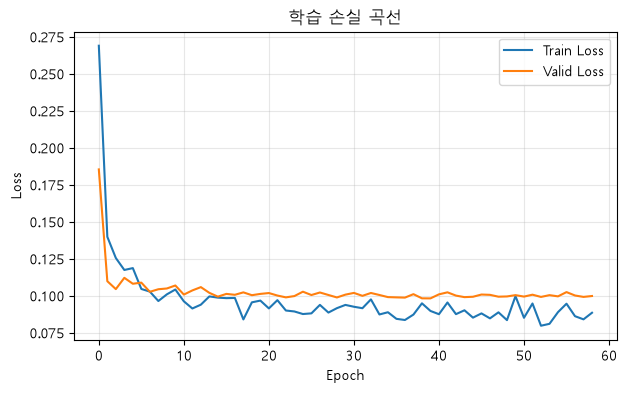

In [29]:
plt.figure(figsize = (7,4))
plt.plot(history["train_loss"], label = "Train Loss")
plt.plot(history["valid_loss"], label = "Valid Loss")
plt.title("학습 손실 곡선")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_24544\3222885375.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


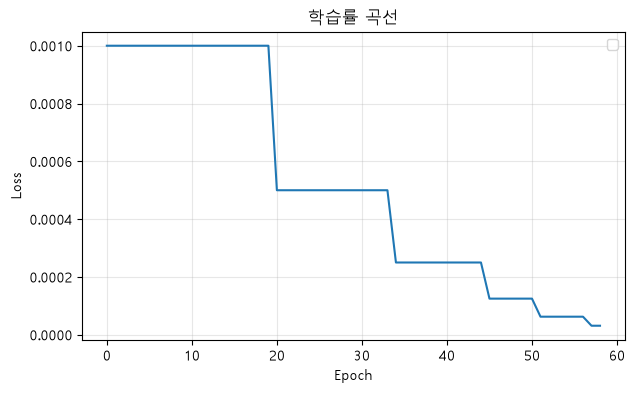

In [30]:
plt.figure(figsize = (7,4))
plt.plot(history["lr"])
plt.title("학습률 곡선")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

14. 테스트 데이터로 최종 평가

In [31]:
# 타겟값을 역변환 시켜주는 함수
def inverse_target(y_scaled):
    y_log_restored = y_scaled * y_std + y_mean  # 정규화 복원

    return np.expm1(y_log_restored)  # log1p 역변환(복원)

def predict_loader(model, data_loader, device):
    model.eval()              # 평가모드
    preds = []           # 예측 확률
    target_list = []          # 정답

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch, in data_loader:
            X_batch = X_batch.to(device)

            output = model(X_batch)
           
            preds.append(output.cpu().numpy())
            target_list.append(y_batch.numpy())

    preds = np.vstack(preds).ravel()       
    y_true = np.vstack(target_list).ravel()       

    return preds, y_true


In [32]:
# test 데이터로 예측
test_pred_scaled, test_true_scaled = predict_loader(model, test_loader, device)

# 학습 데이터 기준으로 전처리된 y 예측값을 원복
test_pred = inverse_target(test_pred_scaled)
test_true = inverse_target(test_true_scaled)

# 3개 회귀 지표
mae = mean_absolute_error(test_true, test_pred)
rmse = np.sqrt(mean_squared_error(test_true, test_pred))
r2 = r2_score(test_true, test_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2-Score : {r2:.4f}")

MAE : 2248.0297
RMSE : 4487.3213
R2-Score : 0.8703


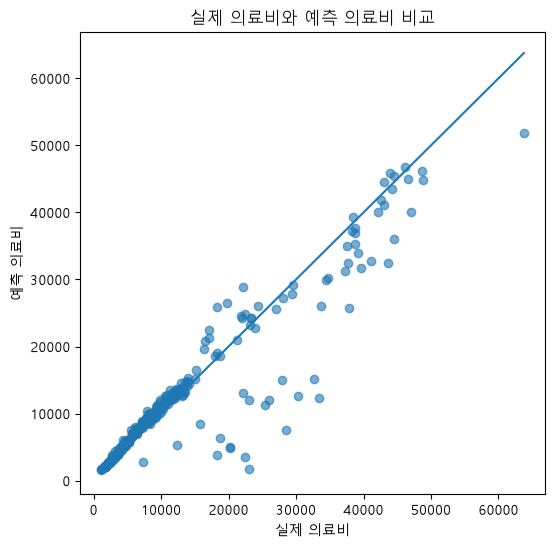

In [ ]:
# 실제값과 예측값 비교 그래프 시각화
plt.figure(figsize = (6,6))
plt.scatter(test_true, test_pred, alpha = 0.6)

# 완벽한 실제값 절대선 : 예측이 오나벽하게 되면 이 대각선 가까이에 점들이 위치
plt.plot(
    [test_true.min(), test_true.max()],
    [test_true.min(), test_true.max()],
)

plt.title("실제 의료비와 예측 의료비 비교")
plt.xlabel("실제 의료비")
plt.ylabel("예측 의료비")
plt.show()


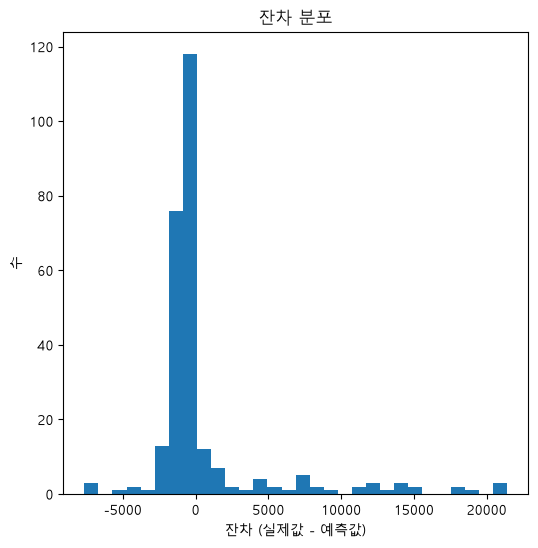

In [35]:
# 잔차 : 실제값과 예측값의 차이 시각화
residuals = test_true - test_pred

plt.figure(figsize=(6,6))
plt.hist(residuals, bins = 30)
plt.title("잔차 분포")
plt.xlabel("잔차 (실제값 - 예측값)")
plt.ylabel("수")
plt.show()

In [36]:
result_df = pd.DataFrame({
    "actual" : test_true,
    "predicted" : test_pred,
    "residuals" : test_true - test_pred
})

result_df.head(10)

,actual,predicted,residuals
0,9095.068247,10168.130560,-1073.062313
1,5272.175875,5764.162069,-491.986194
2,29330.981782,27772.094320,1558.887463
3,9301.893542,9421.966164,-120.072622
4,33750.291595,26119.436578,7630.855017
5,4536.258999,5069.657507,-533.398508
6,2117.338911,2587.385591,-470.046679
7,14210.536124,14455.813602,-245.277478
8,3732.625129,4280.961933,-548.336804
9,10264.442154,10725.201551,-460.759397


15. 임의의 데이터로 테스트


In [38]:
# 새로운 데이터 예측 함수
def predict_charge(new_data, model, preproessor, device):
    new_scaled = preprocessor.transform(new_data)              # 학습 전처리 기준으로 전처리

    new_tensor = torch.FloatTensor(new_scaled).to(device)      # Tensor 변환

    model.eval()                                               # 평가 모드 (Batch Nor, Dropout 비활성화)
    with torch.no_grad():                                      # 평가시에는 계산 비활성화
        pred_scaled = model(new_tensor).cpu().numpy().ravel()  # 의료비 예측 데이터를 1차원 변환

    pred_charge = inverse_target(pred_scaled)                  # 원래 수치 단위로 복원
    return pred_charge


In [45]:
import pandas as pd

sample_data = pd.DataFrame([
    {
        'age' : 35,
        'sex' : "male",
        'bmi' : 27.5,
        "children" : 1,
        'smoker' : "no",  # <-- Added comma here
        'region' : 'southeast'
    },
    {
        'age' : 50,
        'sex' : "female",
        'bmi' : 32.0,
        "children" : 2,
        'smoker' : "yes",  # <-- Added comma here
        'region' : "northwest"
    },
])

predicted_charge = predict_charge(sample_data, model, preprocessor, device)
predicted_charge

array([ 5529.39244384, 34203.18027849])